# 01 — La partición

Se decide qué sujetos son test **antes de calcular nada de la señal**, leyendo solo la
tabla de metadatos. Así la partición no puede estar influida por las características.

62 sujetos de desarrollo y 16 de test, estratificado por quintiles de edad, semilla 42.
Se genera una sola vez: si el archivo ya existe, se verifica y no se toca.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np, pandas as pd
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.axisbelow": True, "font.size": 9})
TINTA, GRIS = "#3a3a3a", "#8a8a8a"
SEMILLA, N_BINS, FRAC_TEST, N_FOLDS = 42, 5, 0.20, 5

RAIZ = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / "Data").is_dir())
SALIDA = Path("../subject_split_seed42.json")

## 1 · Los sujetos

`SC-subjects.xls` trae una fila por noche. La unidad del proyecto es **la persona**, así
que se agrupa por sujeto: la edad es la misma en sus dos noches.

In [2]:
noches = pd.read_excel(RAIZ / "Data" / "SC-subjects.xls")
datos = (noches.groupby("subject")
         .agg(chronological_age=("age", "first"), n_nights=("night", "nunique"))
         .reset_index().rename(columns={"subject": "subject_id"}))

print(f"{len(noches)} noches -> {len(datos)} sujetos · edad "
      f"{datos.chronological_age.min():.0f}-{datos.chronological_age.max():.0f}")
print(f"con 2 noches: {(datos.n_nights == 2).sum()} · con 1: {(datos.n_nights == 1).sum()}")

153 noches -> 78 sujetos · edad 25-101
con 2 noches: 75 · con 1: 3


## 2 · La partición

`StratifiedShuffleSplit` 80/20 sobre quintiles de edad, y dentro del desarrollo un
`StratifiedKFold` de 5. Los quintiles solo sirven para estratificar: **no son
características**.

Si `subject_split_seed42.json` ya existe, se compara con lo generado y se aborta si
difieren. La partición no se cambia nunca — todos los experimentos del proyecto la
reutilizan, y si cada uno sortea la suya las comparaciones dejan de valer.

In [3]:
bins = pd.qcut(datos.chronological_age, q=N_BINS, labels=False, duplicates="drop").values

idx_tv, idx_te = next(StratifiedShuffleSplit(
    n_splits=1, test_size=FRAC_TEST, random_state=SEMILLA).split(datos, bins))
tv, te = datos.iloc[idx_tv], datos.iloc[idx_te]

folds = [{"fold": k,
          "train_subject_ids": sorted(int(s) for s in tv.subject_id.iloc[i]),
          "val_subject_ids":   sorted(int(s) for s in tv.subject_id.iloc[j])}
         for k, (i, j) in enumerate(StratifiedKFold(
             N_FOLDS, shuffle=True, random_state=SEMILLA).split(tv, bins[idx_tv]))]

split = {"seed": SEMILLA,
         "metodo": "StratifiedShuffleSplit 80/20 + StratifiedKFold(5), unidad = sujeto",
         "n_bins_edad": N_BINS, "n_subjects_total": len(datos),
         "train_validation_subject_ids": sorted(int(s) for s in tv.subject_id),
         "test_subject_ids": sorted(int(s) for s in te.subject_id),
         "cv_folds": folds}

if SALIDA.exists():
    previo = json.loads(SALIDA.read_text())
    iguales = all(split[k] == previo[k] for k in
                  ("train_validation_subject_ids", "test_subject_ids", "cv_folds"))
    assert iguales, "La particion generada NO coincide con la guardada. No se sobrescribe."
    print(f"{SALIDA.name} ya existe y coincide -> verificada, no se regenera")
else:
    SALIDA.write_text(json.dumps(split, indent=2, ensure_ascii=False))
    print(f"{SALIDA.name} creado")

TV, TEST = split["train_validation_subject_ids"], split["test_subject_ids"]
edad = datos.set_index("subject_id").chronological_age
print(f"\ndesarrollo {len(TV):2d} sujetos · edad {edad[TV].min():.0f}-{edad[TV].max():.0f}"
      f" · media {edad[TV].mean():.1f}")
print(f"test       {len(TEST):2d} sujetos · edad {edad[TEST].min():.0f}-{edad[TEST].max():.0f}"
      f" · media {edad[TEST].mean():.1f}   [CONGELADO]")
print(f"\ntest: {TEST}")

subject_split_seed42.json ya existe y coincide -> verificada, no se regenera

desarrollo 62 sujetos · edad 25-96 · media 58.2
test       16 sujetos · edad 27-101 · media 61.0   [CONGELADO]

test: [1, 6, 13, 15, 21, 30, 34, 46, 47, 55, 57, 58, 59, 61, 63, 73]


## 3 · Comprobación

Que el test cubra el rango de edades y que los 5 folds estén equilibrados. Y que ningún
sujeto esté en los dos lados.

In [4]:
assert not (set(TV) & set(TEST)), "hay sujetos en desarrollo y en test a la vez"
assert len(set(TV) | set(TEST)) == len(datos), "faltan o sobran sujetos"
for f in split["cv_folds"]:
    assert not (set(f["val_subject_ids"]) & set(TEST)), "un fold toca el test"
print("sin solapamientos: desarrollo y test son disjuntos y cubren los 78 sujetos\n")

filas = [{"fold": f["fold"], "train": len(f["train_subject_ids"]),
          "val": len(f["val_subject_ids"]),
          "edad val (media)": edad[f["val_subject_ids"]].mean()} for f in split["cv_folds"]]
print(pd.DataFrame(filas).round(1).to_string(index=False))

sin solapamientos: desarrollo y test son disjuntos y cubren los 78 sujetos

 fold  train  val  edad val (media)
    0     49   13              60.8
    1     49   13              55.1
    2     50   12              57.4
    3     50   12              58.8
    4     50   12              59.1


### Los grupos de edad

El reclutamiento fue por grupos etarios, así que las edades no son continuas: hay huecos
de 15 y de 10 años sin ningún sujeto. La estratificación reparte el test entre los cuatro
bloques.

In [5]:
e = np.sort(datos.chronological_age.values)
cortes = [(a, b) for a, b in zip(e, e[1:]) if b - a > 4]
grupos, ini = [], e[0]
for a, b in cortes:
    grupos.append((ini, a)); ini = b
grupos.append((ini, e[-1]))

print("grupo         sujetos  desarrollo  test")
for lo, hi in grupos:
    en = datos[(datos.chronological_age >= lo) & (datos.chronological_age <= hi)].subject_id
    n_te = len(set(en) & set(TEST))
    print(f"{lo:3.0f}-{hi:3.0f} años {len(en):8d} {len(en) - n_te:11d} {n_te:5d}")
print("\nhuecos sin ningun sujeto: " +
      " · ".join(f"{a:.0f}-{b:.0f}" for a, b in cortes))

grupo         sujetos  desarrollo  test
 25- 34 años       20          16     4
 50- 60 años       22          19     3
 66- 74 años       20          14     6
 85-101 años       16          13     3

huecos sin ningun sujeto: 34-50 · 60-66 · 74-85


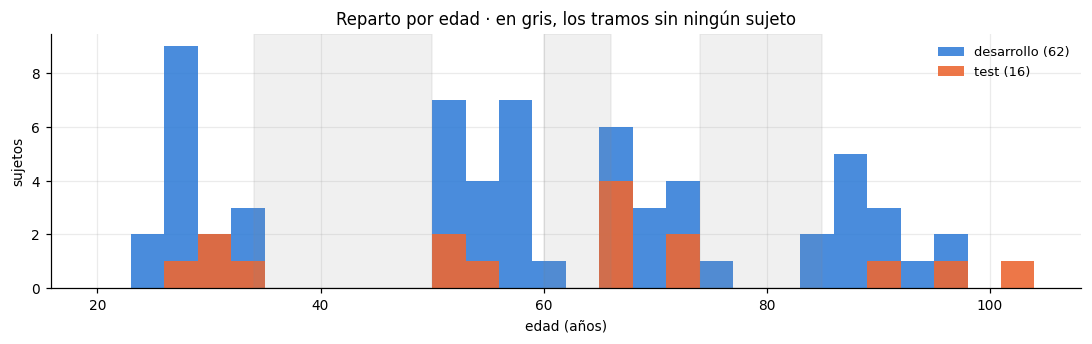

In [6]:
fig, ax = plt.subplots(figsize=(10, 3.2))
bordes = np.arange(20, 106, 3)
ax.hist(edad[TV], bins=bordes, color="#2a78d6", alpha=.85, label=f"desarrollo ({len(TV)})")
ax.hist(edad[TEST], bins=bordes, color="#eb6834", alpha=.9, label=f"test ({len(TEST)})")
for a, b in cortes:
    ax.axvspan(a, b, color=GRIS, alpha=.12)
ax.set(xlabel="edad (años)", ylabel="sujetos",
       title="Reparto por edad · en gris, los tramos sin ningún sujeto")
ax.legend(frameon=False, fontsize=8.5)
plt.tight_layout(); plt.show()

## Conclusión

Partición fija en `Experimentos/subject_split_seed42.json`: **62 de desarrollo, 16 de
test, 5 folds**, estratificada por quintiles de edad.

El test queda congelado hasta el notebook 03. Los 16 sujetos son:
`[1, 6, 13, 15, 21, 30, 34, 46, 47, 55, 57, 58, 59, 61, 63, 73]`.